In [2]:
%pip install pandas xgboost scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
df_cpu = pd.read_csv('/Users/work/Documents/GitHub/xgboost/data_3/cpu_data.csv')
df_gpu = pd.read_csv('/Users/work/Documents/GitHub/xgboost/data_3/gpu_data.csv')

columns_to_drop = ['run_id', 'log_file', 'exit_code', 'device']
df_cpu = df_cpu.drop(columns=[c for c in columns_to_drop if c in df_cpu.columns])
df_gpu = df_gpu.drop(columns=[c for c in columns_to_drop if c in df_gpu.columns])

cols_to_convert = [
    'trial', 'num_sample', 'dense_dim_in', 
    'dense_dim_out', 'read_size_bytes', 'write_size_bytes'
]

for df in [df_cpu, df_gpu]:
    for col in cols_to_convert:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col]).astype('int64')

merge_keys = [
    'trial', 'task_type', 'num_sample', 
    'dense_dim_in', 'dense_dim_out', 
    'read_size_bytes', 'write_size_bytes'
]


df_combined = pd.merge(df_cpu, df_gpu, on=merge_keys, suffixes=('_cpu', '_gpu'))
df_combined = df_combined.drop(columns=['transfer_h2d_total_s_cpu'], errors='ignore')

# calculate power
CPU_POWER_W = 185
GPU_POWER_W = 400

df_combined["cpu_power_w"] = CPU_POWER_W
df_combined["gpu_power_w"] = GPU_POWER_W

df_combined["cpu_energy_j"] = (
    CPU_POWER_W
    * (df_combined["cpu_utilization"])
    * df_combined["runtime_wall_s_cpu"]
)

df_combined["gpu_energy_j"] = (
    GPU_POWER_W
    * (df_combined["gpu_util_avg_pct"] / 100.0)
    * df_combined["runtime_wall_s_gpu"]
)

#average metrics
workload_keys = [
    'task_type', 'num_sample', 'dense_dim_in', 
    'dense_dim_out', 'read_size_bytes', 'write_size_bytes'
]

df_avg = df_combined.groupby(workload_keys, as_index=False).mean(numeric_only=True)

#normalize
max_time = max(df_avg['runtime_wall_s_cpu'].max(), df_avg['runtime_wall_s_gpu'].max())
min_time = min(df_avg['runtime_wall_s_cpu'].min(), df_avg['runtime_wall_s_gpu'].min())
df_avg['norm_time_cpu'] = (df_avg['runtime_wall_s_cpu'] - min_time) / (max_time - min_time)
df_avg['norm_time_gpu'] = (df_avg['runtime_wall_s_gpu'] - min_time) / (max_time - min_time)

max_energy = max(df_avg['cpu_energy_j'].max(), df_avg['gpu_energy_j'].max())
min_energy = min(df_avg['cpu_energy_j'].min(), df_avg['gpu_energy_j'].min())
df_avg['norm_energy_cpu'] = (df_avg['cpu_energy_j'] - min_energy) / (max_energy - min_energy)
df_avg['norm_energy_gpu'] = (df_avg['gpu_energy_j'] - min_energy) / (max_energy - min_energy)

W_TIME = 0.5
W_ENERGY = 0.5

df_avg['cpu_cost'] = (W_TIME * df_avg['norm_time_cpu'] + W_ENERGY * df_avg['norm_energy_cpu'])
df_avg['gpu_cost'] = (W_TIME * df_avg['norm_time_gpu'] + W_ENERGY * df_avg['norm_energy_gpu'])
df_avg['optimal_device'] = np.where(df_avg['cpu_cost'] < df_avg['gpu_cost'], 0, 1)


drop_cols = [
    'trial', 'optimal_device', 'cpu_cost', 'gpu_cost',
    'norm_time_cpu', 'norm_time_gpu', 'norm_energy_cpu', 'norm_energy_gpu',
    'runtime_wall_s_cpu', 'runtime_reported_s_cpu', 'cpu_energy_j', 
    'cpu_utilization', 'cpu_power_w', 'cpu_ghz',
    'runtime_wall_s_gpu', 'runtime_reported_s_gpu', 'gpu_energy_j', 
    'gpu_util_avg_pct', 'gpu_util_max_pct', 'gpu_power_w', 
    'gpu_sm_clock_avg_ghz', 'gpu_sm_clock_max_ghz', 'monitored_gpu',
    'transfer_h2d_total_s', 'transfer_h2d_s', 'transfer_d2h_s', 'num_sample'
]

X = df_avg.drop(columns=[c for c in drop_cols if c in df_avg.columns])

X = pd.get_dummies(X, drop_first=True)
y = df_avg['optimal_device']

In [4]:
print(f"Total features: {X.shape[1]}")
print(X.columns.tolist())

Total features: 5
['dense_dim_in', 'dense_dim_out', 'read_size_bytes', 'write_size_bytes', 'task_type_new_training']


# Training XGBoost

In [5]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)
print(f"training: {X_train.shape[0]}")
print(f"training: {X_test.shape[0]}")

training: 179
training: 45


In [6]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import xgboost as xgb

model = xgb.XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=50,
    random_state=42
)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(model, X, y, cv=kf)
model.fit(X, y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Evaluating XGBoost

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix")
print(confusion_matrix(y, y_pred))

print(" Classification Report ")
print(classification_report(y, y_pred, target_names=['CPU', 'GPU']))

Confusion Matrix
[[126   2]
 [  2  94]]
 Classification Report 
              precision    recall  f1-score   support

         CPU       0.98      0.98      0.98       128
         GPU       0.98      0.98      0.98        96

    accuracy                           0.98       224
   macro avg       0.98      0.98      0.98       224
weighted avg       0.98      0.98      0.98       224



In [8]:
import pandas as pd
from tabulate import tabulate
from sklearn.metrics import classification_report

report_dict = classification_report(
    y, y_pred, 
    target_names=['CPU', 'GPU'], 
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose().round(2)

print(tabulate(df_report, headers='keys', tablefmt='psql'))

+--------------+-------------+----------+------------+-----------+
|              |   precision |   recall |   f1-score |   support |
|--------------+-------------+----------+------------+-----------|
| CPU          |        0.98 |     0.98 |       0.98 |    128    |
| GPU          |        0.98 |     0.98 |       0.98 |     96    |
| accuracy     |        0.98 |     0.98 |       0.98 |      0.98 |
| macro avg    |        0.98 |     0.98 |       0.98 |    224    |
| weighted avg |        0.98 |     0.98 |       0.98 |    224    |
+--------------+-------------+----------+------------+-----------+


### Confusion Matrix

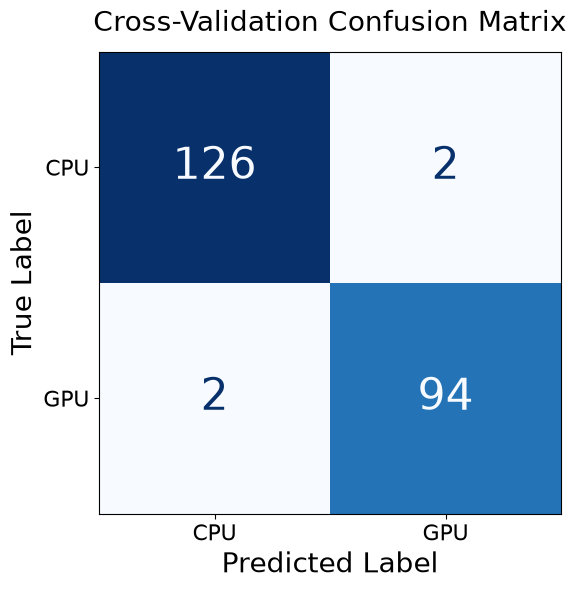

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['CPU', 'GPU'], )
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False, text_kw={'fontsize': 32})
ax.tick_params(axis='both', which='major', labelsize=16)

plt.title('Cross-Validation Confusion Matrix', fontsize=20, pad=15)
plt.xlabel('Predicted Label', fontsize=20)
plt.ylabel('True Label', fontsize=20)
plt.grid(False) 
plt.show()

### Test against CPU/GPU only 

In [ ]:
import numpy as np
import pandas as pd

model_time = np.where(y_pred == 0, df_avg['runtime_wall_s_cpu'], df_avg['runtime_wall_s_gpu'])
model_energy = np.where(y_pred == 0, df_avg['cpu_energy_j'], df_avg['gpu_energy_j'])

rr_decisions = np.arange(len(df_avg)) % 2  
rr_time = np.where(rr_decisions == 0, df_avg['runtime_wall_s_cpu'], df_avg['runtime_wall_s_gpu'])
rr_energy = np.where(rr_decisions == 0, df_avg['cpu_energy_j'], df_avg['gpu_energy_j'])

total_cpu_time = df_avg['runtime_wall_s_cpu'].sum()
total_gpu_time = df_avg['runtime_wall_s_gpu'].sum()
total_rr_time = rr_time.sum()
total_model_time = model_time.sum()

total_cpu_energy = df_avg['cpu_energy_j'].sum()
total_gpu_energy = df_avg['gpu_energy_j'].sum()
total_rr_energy = rr_energy.sum()
total_model_energy = model_energy.sum()

print("Time")
print(f"CPU Only:        {total_cpu_time:.2f} s")
print(f"GPU Only:        {total_gpu_time:.2f} s")
print(f"Round Robin:     {total_rr_time:.2f} s")
print(f"XGBoost Model:   {total_model_time:.2f} s")
print(f"Model vs CPU:    {total_cpu_time - total_model_time:.2f} s saved ({((1 - total_model_time/total_cpu_time)*100):.1f}% faster)")
print(f"Model vs GPU:    {total_gpu_time - total_model_time:.2f} s saved ({((1 - total_model_time/total_gpu_time)*100):.1f}% faster)")
print(f"Model vs RR:     {total_rr_time - total_model_time:.2f} s saved ({((1 - total_model_time/total_rr_time)*100):.1f}% faster)")

print("Energy")
print(f"CPU Only:        {total_cpu_energy:.2f} J")
print(f"GPU Only:        {total_gpu_energy:.2f} J")
print(f"Round Robin:     {total_rr_energy:.2f} J")
print(f"XGBoost Model:   {total_model_energy:.2f} J")
print(f"Model vs CPU:    {total_cpu_energy - total_model_energy:.2f} J saved ({((1 - total_model_energy/total_cpu_energy)*100):.1f}% reduction)")
print(f"Model vs GPU:    {total_gpu_energy - total_model_energy:.2f} J saved ({((1 - total_model_energy/total_gpu_energy)*100):.1f}% reduction)")
print(f"Model vs RR:     {total_rr_energy - total_model_energy:.2f} J saved ({((1 - total_model_energy/total_rr_energy)*100):.1f}% reduction)")

=== Wall-Clock Time Metrics ===
CPU Only:        23104.99 s
GPU Only:        523.62 s
Round Robin:     11822.85 s
XGBoost Model:   433.16 s
-----------------------------------
Model vs CPU:    22671.83 s saved (98.1% faster)
Model vs GPU:    90.45 s saved (17.3% faster)
Model vs RR:     11389.69 s saved (96.3% faster)

=== Energy Consumption Metrics ===
CPU Only:        4259260.98 J
GPU Only:        65952.13 J
Round Robin:     2163766.78 J
XGBoost Model:   74095.98 J
-----------------------------------
Model vs CPU:    4185165.00 J saved (98.3% reduction)
Model vs GPU:    -8143.85 J saved (-12.3% reduction)
Model vs RR:     2089670.80 J saved (96.6% reduction)


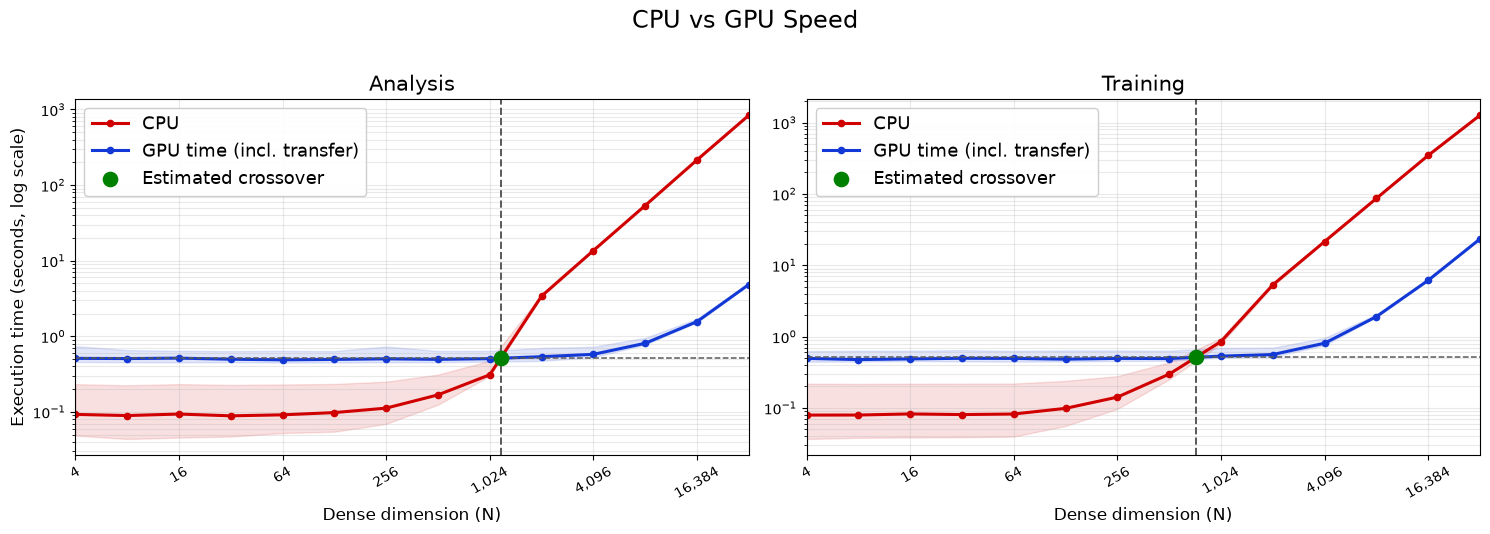

In [58]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data_dir = Path.cwd()
cpu = pd.read_csv(data_dir / 'cpu_data.csv')
gpu = pd.read_csv(data_dir / 'gpu_data.csv')

cpu['execution_s'] = cpu['runtime_reported_s'].fillna(cpu['runtime_wall_s'])
gpu['execution_s'] = gpu['runtime_reported_s'].fillna(gpu['runtime_wall_s'])
h2d = 'transfer_h2d_s' if 'transfer_h2d_s' in gpu else 'transfer_h2d_total_s'
gpu['execution_s'] += gpu[h2d].fillna(0)
if 'transfer_d2h_s' in gpu:
    gpu['execution_s'] += gpu['transfer_d2h_s'].fillna(0)

def summarize_metric(cpu, gpu, metric):
    keep = ['task_type', 'dense_dim_in', metric]
    data = pd.concat([cpu[keep].assign(device='CPU'), gpu[keep].assign(device='GPU')])
    return (data.groupby(['task_type', 'device', 'dense_dim_in'])[metric]
            .agg(median='median', q25=lambda x: x.quantile(.25),
                 q75=lambda x: x.quantile(.75)).reset_index())

def find_crossover(cpu_line, gpu_line):
    paired = cpu_line[['dense_dim_in', 'median']].merge(
        gpu_line[['dense_dim_in', 'median']], on='dense_dim_in',
        suffixes=('_cpu', '_gpu')).sort_values('dense_dim_in')
    difference = np.log(paired['median_cpu']) - np.log(paired['median_gpu'])
    changes = np.flatnonzero(np.sign(difference.values[:-1]) != np.sign(difference.values[1:]))
    if len(changes) == 0:
        return None
    i = changes[0]
    x0, x1 = np.log2(paired['dense_dim_in'].iloc[[i, i + 1]].to_numpy(float))
    fraction = -difference.iloc[i] / (difference.iloc[i + 1] - difference.iloc[i])
    cross_x = 2 ** (x0 + fraction * (x1 - x0))
    y0, y1 = np.log(paired['median_cpu'].iloc[[i, i + 1]].to_numpy(float))
    cross_y = np.exp(y0 + fraction * (y1 - y0))
    return cross_x, cross_y

task_labels = {'new_agent': 'Analysis', 'new_training': 'Training'}
colors = {'CPU': '#d00000', 'GPU': '#1239d6'}
FONT_SIZES = {
    'figure_title': 17, 'panel_title': 15, 'axis_label': 12,
    'tick': 10, 'legend': 13, 'annotation': 10, 'zone': 11,
}

def plot_metric(summary, figure_title, ylabel, unit, gpu_label='GPU'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
    for ax, (task, title) in zip(axes, task_labels.items()):
        task_data = summary[summary['task_type'].eq(task)]
        lines = {}
        for device in ['CPU', 'GPU']:
            line = task_data[task_data['device'].eq(device)].sort_values('dense_dim_in')
            lines[device] = line
            x = line['dense_dim_in'].to_numpy(float)
            label = device if device == 'CPU' else gpu_label
            ax.plot(x, line['median'], 'o-', color=colors[device], lw=2.2, ms=4.5, label=label)
            ax.fill_between(x, line['q25'], line['q75'], color=colors[device], alpha=.12)

        xmin, xmax = task_data['dense_dim_in'].min(), task_data['dense_dim_in'].max()
        cross = find_crossover(lines['CPU'], lines['GPU'])
        if cross:
            cross_x, cross_y = cross
            ax.axvline(cross_x, color='.35', ls='--', lw=1.4)
            ax.axhline(cross_y, color='.35', ls='--', lw=1.1)
            ax.scatter(cross_x, cross_y, s=105, color='green', zorder=5, label='Estimated crossover')
            

        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        dims = np.sort(task_data['dense_dim_in'].unique())
        ax.set_xticks(dims[::2], [f'{int(v):,}' for v in dims[::2]], rotation=30)
        ax.set_xlim(xmin, xmax)
        ax.set_title(title, fontsize=FONT_SIZES['panel_title'])
        ax.set_xlabel('Dense dimension (N)', fontsize=FONT_SIZES['axis_label'])
        ax.tick_params(labelsize=FONT_SIZES['tick'])
        ax.grid(True, which='both', alpha=.28)
        ax.legend(loc='upper left', framealpha=.95, fontsize=FONT_SIZES['legend'])

    axes[0].set_ylabel(ylabel, fontsize=FONT_SIZES['axis_label'])
    fig.suptitle(figure_title, fontsize=FONT_SIZES['figure_title'])
    fig.tight_layout(rect=(0, .035, 1, .96))
    plt.show()

time_summary = summarize_metric(cpu, gpu, 'execution_s')
plot_metric(time_summary, 'CPU vs GPU Speed', 'Execution time (seconds, log scale)',
            'Time', gpu_label='GPU time (incl. transfer)')

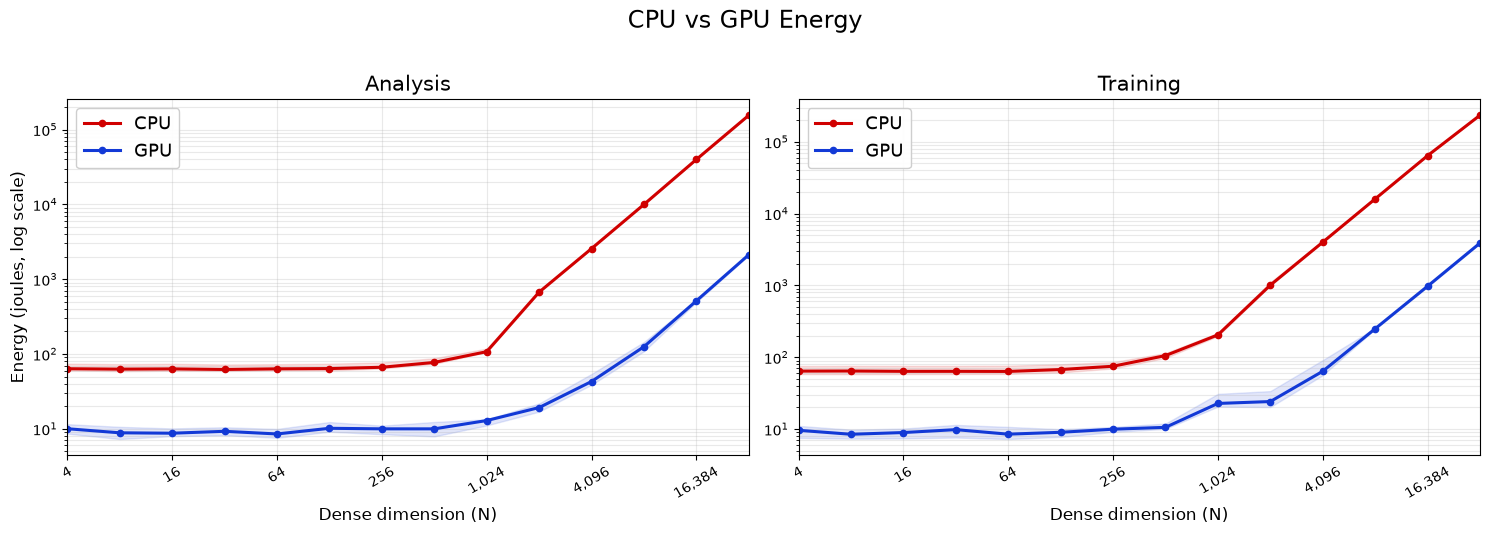

In [47]:
CPU_POWER_W = 185
GPU_POWER_W = 400
cpu['energy_j'] = CPU_POWER_W * cpu['cpu_utilization'] * cpu['runtime_wall_s']
gpu['energy_j'] = GPU_POWER_W * (gpu['gpu_util_avg_pct'] / 100) * gpu['runtime_wall_s']

energy_summary = summarize_metric(cpu, gpu, 'energy_j')
plot_metric(energy_summary, 'CPU vs GPU Energy', 'Energy (joules, log scale)', 'Energy')